<a href="https://www.kaggle.com/code/ghadaelfeki/notebookmall-customer-segmentation-ml-project-gh?scriptVersionId=342435472" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Mall Customer Segmentation Using Unsupervised Machine Learning

Project Goal

Segment mall customers into distinct groups based on their spending behavior and demographics using clustering algorithms. The insights can help businesses design targeted marketing strategies and personalize customer engagement.

Dataset 

Dataset The dataset used in this project was obtained from Kaggle. Original Dataset:
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data

 Thanks to the dataset author for making this data publicly available.

Content

we are owing a supermarket mall and through membership cards , we have some basic data about teh customers like Customer ID, age, gender, annual income and spending score.
Spending Score is something we assign to the customer based on our defined parameters like customer behavior and purchasing data.

Problem Statement
we own the mall and want to understand the customers like who can be easily converge [Target Customers] so that the sense can be given to marketing team and plan the strategy accordingly. 

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage


import warnings
warnings.filterwarnings("ignore")

## Create Output Folders Automatically

In [2]:
folders = [

    "images",

    "results",

    "reports"

]

for folder in folders:

    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


## Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ghadaelfeki/mall-customer-segmentation-ml-project-gh/Mall_Customers.csv')

## Explore Dataset

In [4]:
print(df.head())

print()

print(df.info())

print()

print(df.describe())

print()

print(df.shape)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

       CustomerID         Age  Annual Income (k$)

## Check Missing Values

In [5]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Remove Duplicates

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


## Data Types

In [7]:
print(df.dtypes)

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


## Save Dataset Summary

In [8]:
summary = df.describe()

summary.to_csv("results/descriptive_statistics.csv")

## Exploratory Data Analysis (EDA)

Histograms

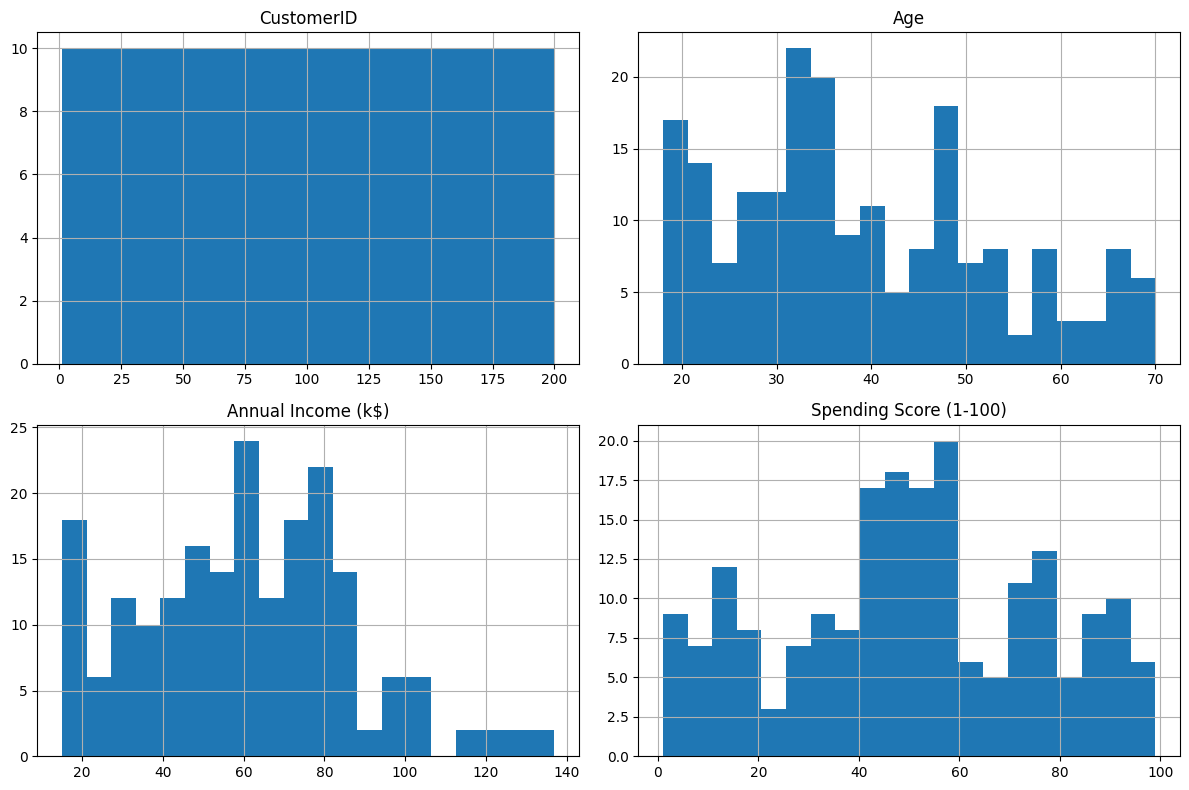

In [9]:
df.hist(

    figsize=(12,8),

    bins=20

)

plt.tight_layout()

plt.savefig(

    "images/histograms.png",

    dpi=300

)

plt.show()

## Correlation Heatmap

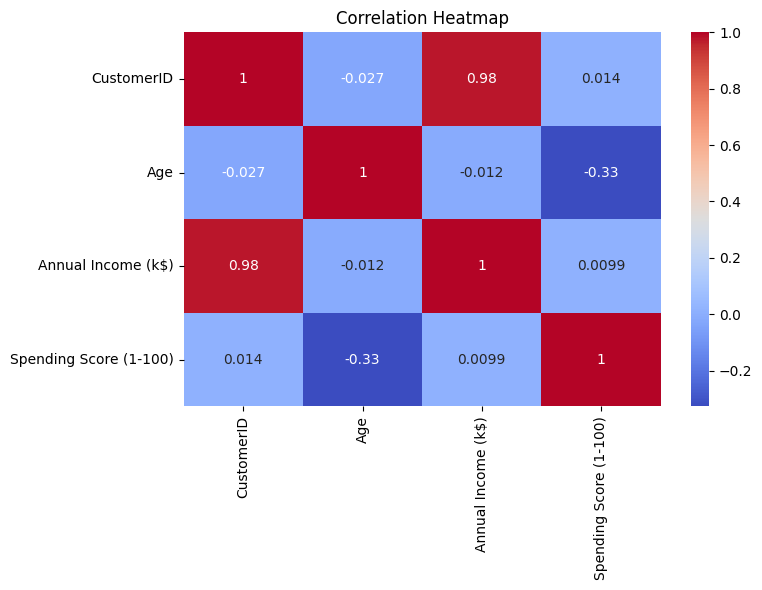

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(

    df.corr(numeric_only=True),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(

    "images/correlation_heatmap.png",

    dpi=300

)

plt.show()

## Pairplot

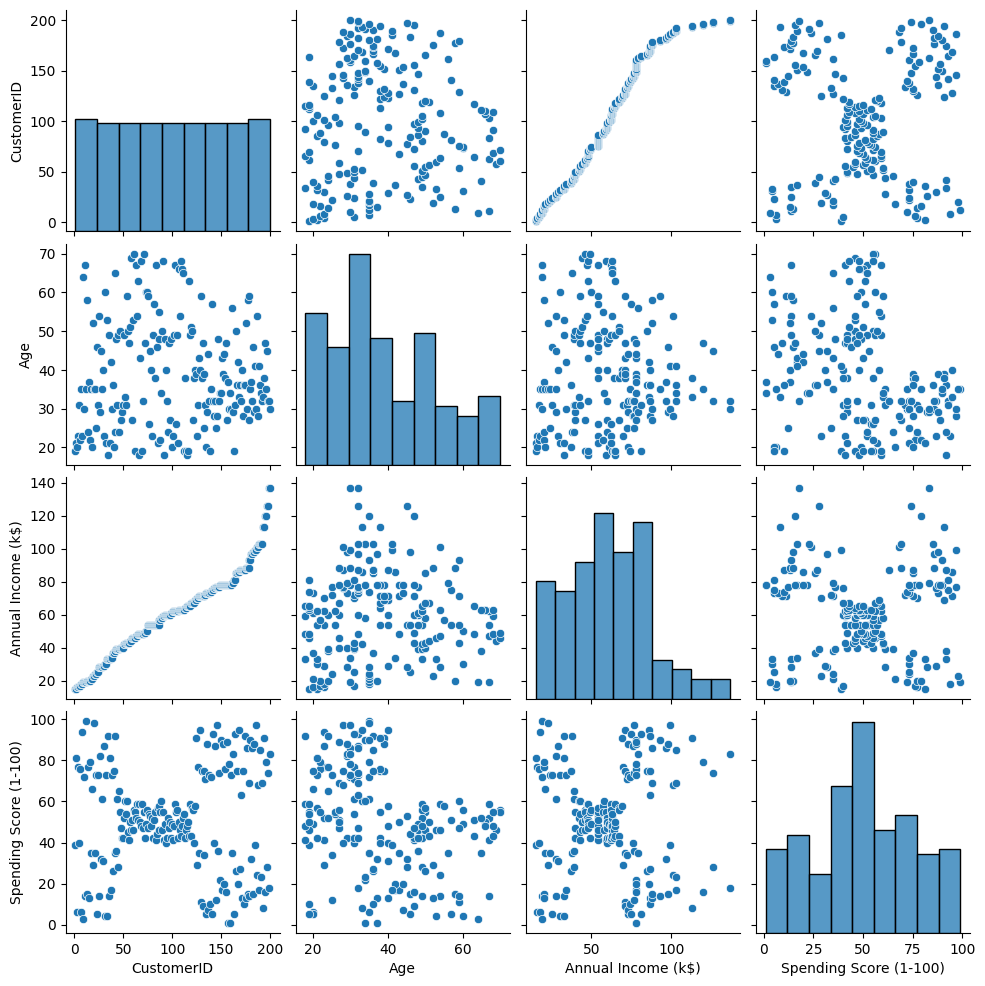

In [11]:
pair = sns.pairplot(

    df,

    diag_kind="hist"

)

pair.savefig(

    "images/pairplot.png"
)

plt.show()


## Boxplots (Outlier Detection)

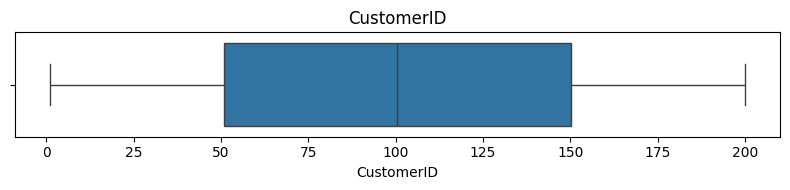

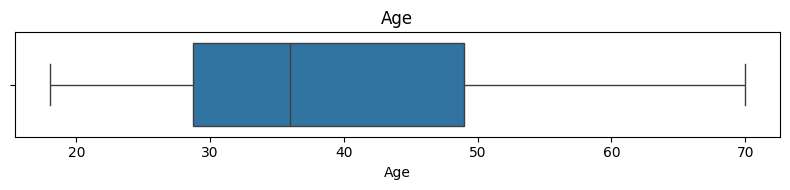

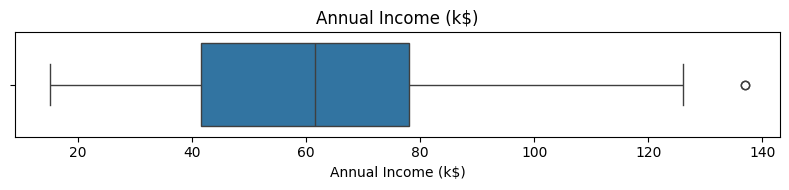

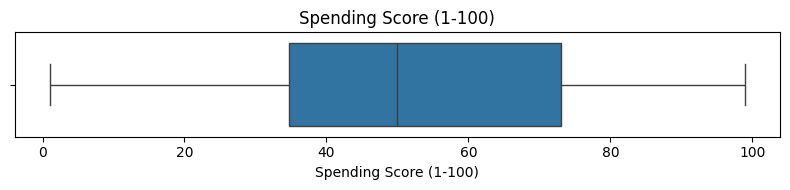

In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(

        x=df[column]

    )

    plt.title(column)

    plt.tight_layout()

    plt.savefig(

        f"images/boxplot_{column}.png",

        dpi=300

    )

    plt.show()

## Feature Selection

For clustering we'll use:

Annual Income
Spending Score

In [13]:
X = df[

    [

        "Annual Income (k$)",

        "Spending Score (1-100)"

    ]

]

## Feature Scaling

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Determine the Optimal Number of Clusters (Elbow Method)

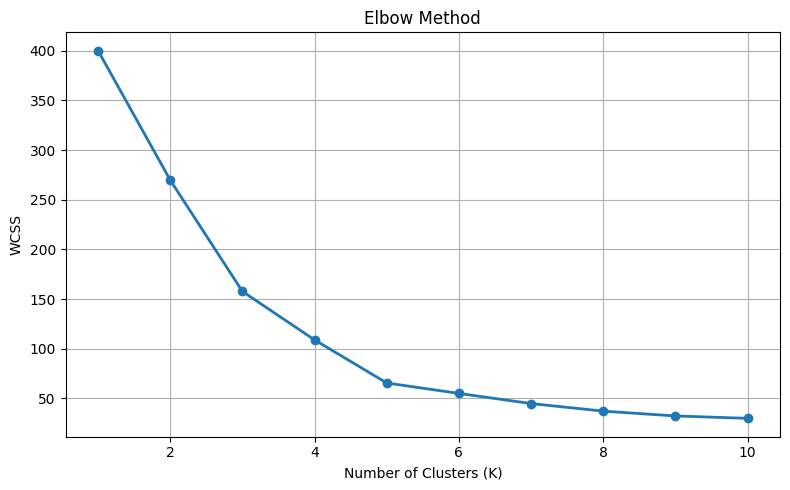

In [15]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/elbow_curve.png",
    dpi=300
)

plt.show()

## Silhouette Score Analysis

   Clusters  Silhouette Score
0         2          0.321271
1         3          0.466585
2         4          0.493907
3         5          0.554657
4         6          0.539880
5         7          0.528149
6         8          0.455215
7         9          0.457085
8        10          0.443171


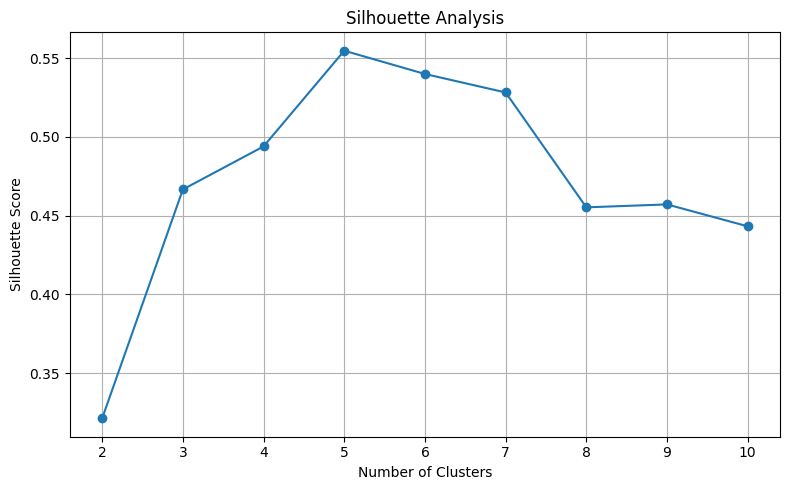

In [16]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

results = pd.DataFrame({

    "Clusters":range(2,11),

    "Silhouette Score":silhouette_scores

})

print(results)

results.to_csv(
    "results/silhouette_scores.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/silhouette_score.png",
    dpi=300
)

plt.show()

## Train the Final K-Means Model

Assume the best value is K = 5 (common for this dataset; adjust if your elbow/silhouette results suggest otherwise).

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

## View Cluster Sizes

In [18]:
cluster_count = df["Cluster"].value_counts().sort_index()

print(cluster_count)

cluster_count.to_csv(
    "results/cluster_sizes.csv"
)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Visualize Customer Clusters

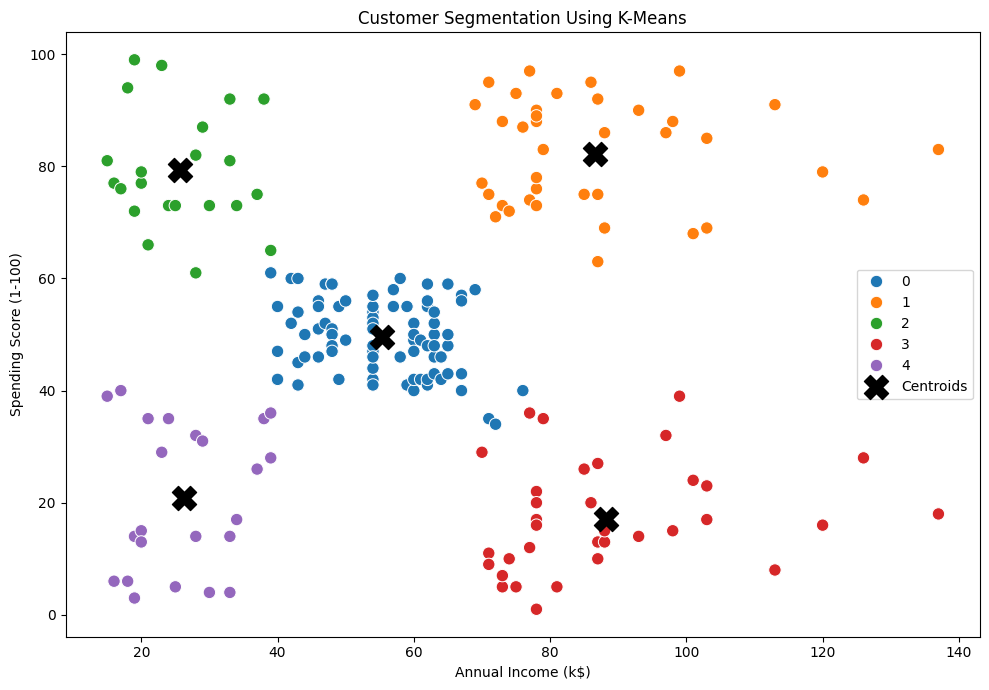

In [19]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=df,

    x="Annual Income (k$)",

    y="Spending Score (1-100)",

    hue="Cluster",

    palette="tab10",

    s=80

)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(

    centers[:,0],

    centers[:,1],

    s=300,

    marker="X",

    c="black",

    label="Centroids"

)

plt.title("Customer Segmentation Using K-Means")

plt.legend()

plt.tight_layout()

plt.savefig(

    "images/kmeans_clusters.png",

    dpi=300

)

plt.show()

## Cluster Profiling

In [20]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_profile)

cluster_profile.to_csv(
    "results/cluster_profile.csv"
)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


## Export Clustered Dataset

In [21]:
df.to_csv(

    "results/Mall_Customers_Clustered.csv",

    index=False

)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


## Save the Trained K-Means Model

In [22]:
import joblib

joblib.dump(

    kmeans,

    "results/kmeans_model.pkl"

)

print("K-Means model saved.")

K-Means model saved.


## PCA Visualization (2D)

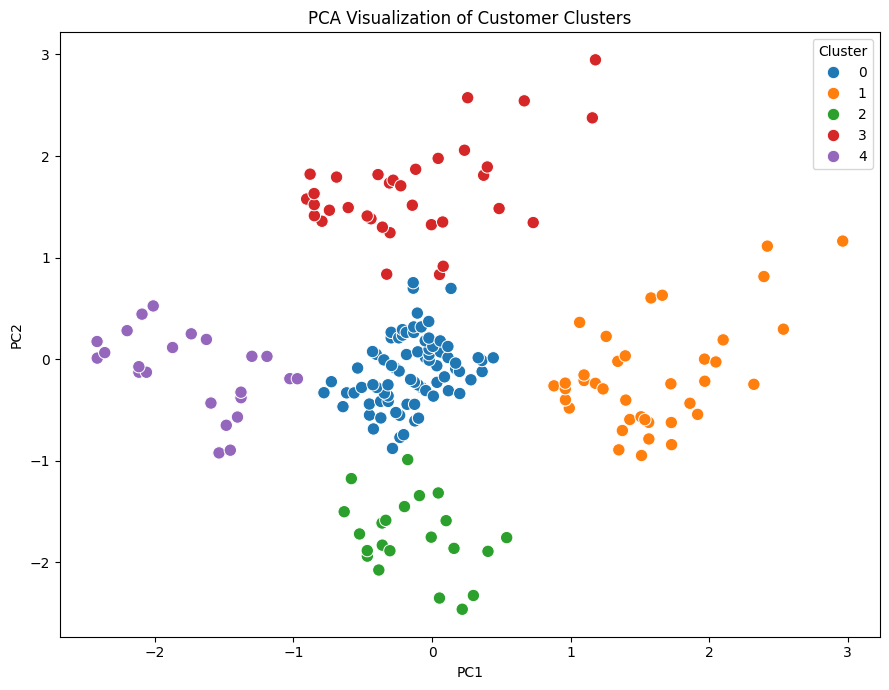

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({

    "PC1": X_pca[:,0],

    "PC2": X_pca[:,1],

    "Cluster": clusters

})

plt.figure(figsize=(9,7))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="tab10",

    s=80

)

plt.title("PCA Visualization of Customer Clusters")

plt.tight_layout()

plt.savefig(

    "images/pca_clusters.png",

    dpi=300

)

plt.show()

## Hierarchical Clustering (Dendrogram)

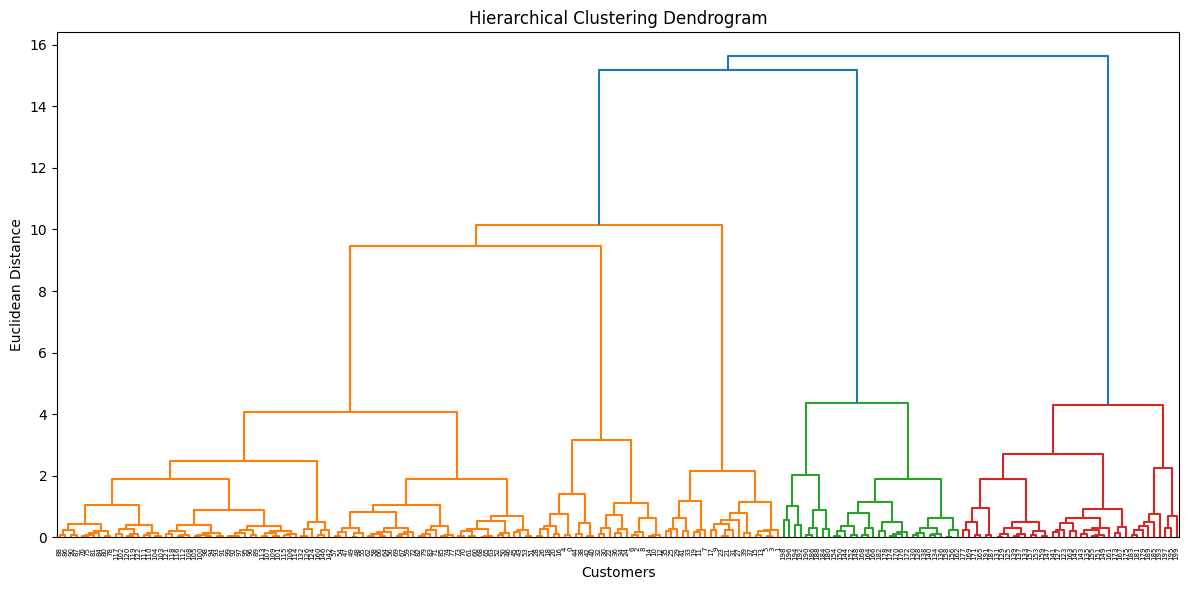

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.tight_layout()

plt.savefig(
    "images/hierarchical_dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Agglomerative Hierarchical Clustering

In [25]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)

hc_labels = hc.fit_predict(X_scaled)

df["Hierarchical Cluster"] = hc_labels

## Plot Hierarchical Clusters

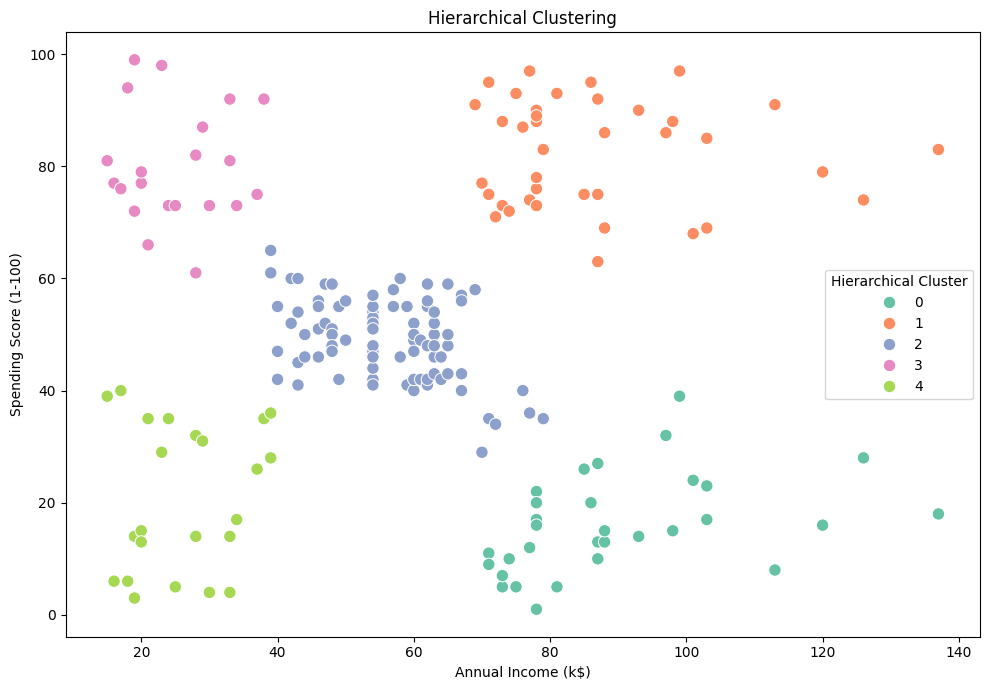

In [26]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Hierarchical Cluster",
    palette="Set2",
    s=80
)

plt.title("Hierarchical Clustering")

plt.tight_layout()

plt.savefig(
    "images/hierarchical_clusters.png",
    dpi=300
)

plt.show()

## DBSCAN Clustering

In [27]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN Cluster"] = db_labels

print(df["DBSCAN Cluster"].value_counts())

DBSCAN Cluster
 0    195
-1      5
Name: count, dtype: int64


## Plot DBSCAN Clusters

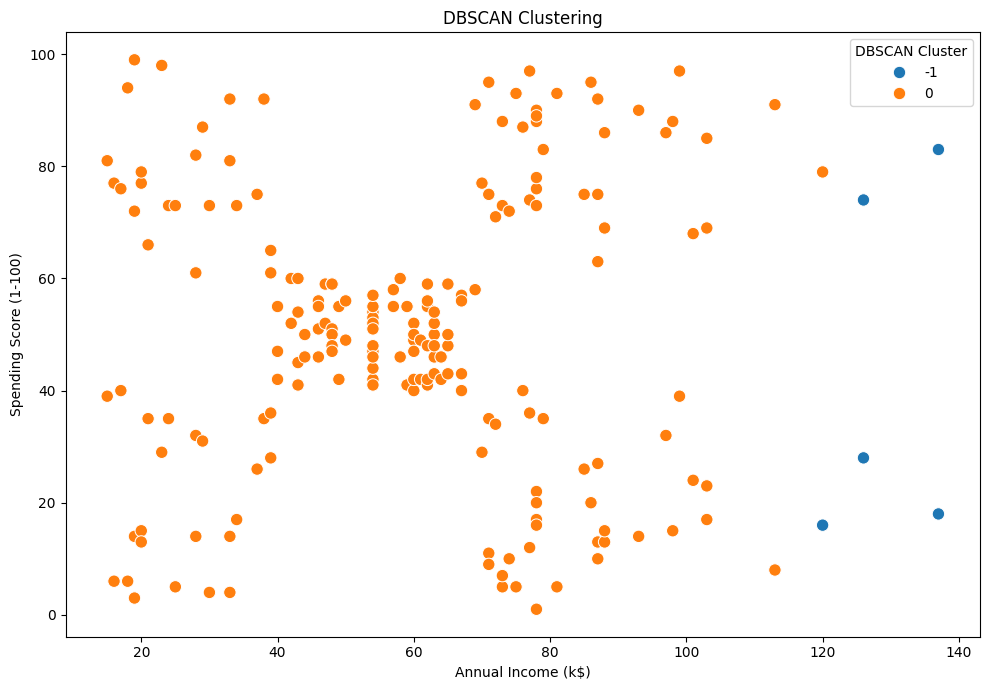

In [28]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="DBSCAN Cluster",
    palette="tab10",
    s=80
)

plt.title("DBSCAN Clustering")

plt.tight_layout()

plt.savefig(
    "images/dbscan_clusters.png",
    dpi=300
)

plt.show()

## Compare Clustering Algorithms

In [29]:
comparison = pd.DataFrame({

    "KMeans":df["Cluster"],

    "Hierarchical":df["Hierarchical Cluster"],

    "DBSCAN":df["DBSCAN Cluster"]

})

comparison.to_csv(
    "results/clustering_comparison.csv",
    index=False
)

comparison.head()

,KMeans,Hierarchical,DBSCAN
0,4,4,0
1,2,3,0
2,4,4,0
3,2,3,0
4,4,4,0


## Compare Silhouette Scores

In [30]:
from sklearn.metrics import silhouette_score

scores = {}

scores["KMeans"] = silhouette_score(
    X_scaled,
    df["Cluster"]
)

scores["Hierarchical"] = silhouette_score(
    X_scaled,
    df["Hierarchical Cluster"]
)

valid = df["DBSCAN Cluster"] != -1

if valid.sum() > 1 and len(set(df.loc[valid, "DBSCAN Cluster"])) > 1:
    scores["DBSCAN"] = silhouette_score(
        X_scaled[valid],
        df.loc[valid, "DBSCAN Cluster"]
    )
else:
    scores["DBSCAN"] = None

score_df = pd.DataFrame(
    scores.items(),
    columns=["Algorithm","Silhouette Score"]
)

print(score_df)

score_df.to_csv(
    "results/algorithm_comparison.csv",
    index=False
)

      Algorithm  Silhouette Score
0        KMeans          0.554657
1  Hierarchical          0.553809
2        DBSCAN               NaN


## Bar Chart Comparison

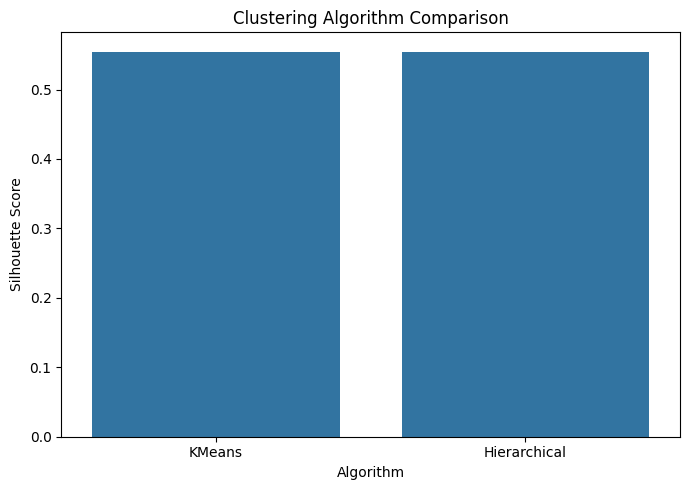

In [31]:
plot_df = score_df.dropna()

plt.figure(figsize=(7,5))

sns.barplot(
    data=plot_df,
    x="Algorithm",
    y="Silhouette Score"
)

plt.title("Clustering Algorithm Comparison")

plt.tight_layout()

plt.savefig(
    "images/algorithm_comparison.png",
    dpi=300
)

plt.show()

## Cluster Profile Visualization

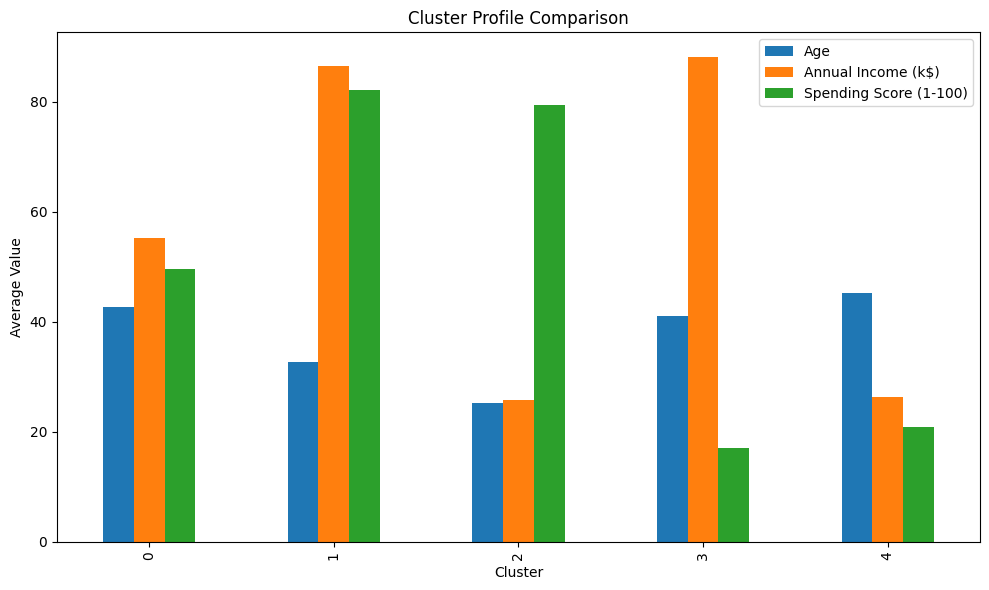

In [32]:
cluster_profile = df.groupby("Cluster")[

    ["Age",
     "Annual Income (k$)",
     "Spending Score (1-100)"]

].mean()

cluster_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Cluster Profile Comparison")

plt.ylabel("Average Value")

plt.tight_layout()

plt.savefig(
    "images/cluster_profile.png",
    dpi=300
)

plt.show()

cluster_profile.to_csv(
    "results/cluster_profile.csv"
)